In [ ]:
import time, datetime
import numpy as np
import pandas as pd
from packaging import version

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as k

print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version:", tf.__version__)
assert version.parse(tf.__version__).release[0] >= 2

np.set_printoptions(precision=3, suppress=True)


This notebook requires TensorFlow 2.0 or above
TensorFlow version: 2.19.0


In [ ]:
def display_training_curves(training, validation, title, subplot):
    ax = plt.subplot(subplot)
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model ' + title)
    ax.set_ylabel(title)
    ax.set_xlabel('epoch')
    ax.legend(['training', 'validation'])

def print_validation_report(y_test, predictions):
    print("Classification Report")
    print(classification_report(y_test, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(y_test, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(y_test, predictions))))

def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75, cbar=False,
                ax=ax, cmap='Blues', linecolor='white')
    plt.ylabel('true label')
    plt.xlabel('predicted label')
    plt.show()



In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print('train_images:\t{}'.format(x_train.shape))
print('train_labels:\t{}'.format(y_train.shape))
print('test_images:\t\t{}'.format(x_test.shape))
print('test_labels:\t\t{}'.format(y_test.shape))

print("First ten labels training dataset:\n {}\n".format(y_train[0:10]))
print("This output the numeric label, need to convert to item description")

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
train_images:	(50000, 32, 32, 3)
train_labels:	(50000, 1)
test_images:		(10000, 32, 32, 3)
test_labels:		(10000, 1)
First ten labels training dataset:
 [[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]

This output the numeric label, need to convert to item description


In [ ]:
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=.1
)

print(x_train_split.shape, x_valid_split.shape, x_test.shape)

x_train_norm = x_train_split/255
x_valid_norm = x_valid_split/255
x_test_norm  = x_test/255


(45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
def compile_train_model(model, x_train, y_train, x_valid, y_valid, epochs=200, batch_size=64):
    # Compile (matches your prof’s later Part 1 version)
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    start_time = time.time()
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_valid, y_valid),
        callbacks=[
            tf.keras.callbacks.ModelCheckpoint("CNN_model.keras", save_best_only=True, save_weights_only=False),
            tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3),
        ]
    )
    end_time = time.time()
    seconds_elapsed = round(end_time - start_time, 2)

    print(f'Finished model training in {seconds_elapsed}s')
    return history, seconds_elapsed


In [ ]:
def plot_history_df(history):
    history_dict = history.history
    history_df = pd.DataFrame(history_dict)

    plt.subplots(figsize=(16,12))
    plt.tight_layout()
    display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
    display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)
    plt.show()

    return history_df


# Experiment 1: DNN with 2 hidden layers (NO regularization)

In [ ]:
k.clear_session()

dnn2 = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(384, activation='relu'),
    Dense(192, activation='relu'),
    Dense(10, activation='softmax')
])

dnn2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │     1,180,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,255,882 (4.79 MB)

 Trainable params: 1,255,882 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2782 - loss: 2.0215 - val_accuracy: 0.3746 - val_loss: 1.7512
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3829 - loss: 1.7169 - val_accuracy: 0.4018 - val_loss: 1.6691
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4199 - loss: 1.6166 - val_accuracy: 0.4312 - val_loss: 1.6063
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4458 - loss: 1.5595 - val_accuracy: 0.4398 - val_loss: 1.5855
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4639 - loss: 1.5071 - val_accuracy: 0.4332 - val_loss: 1.5983
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4694 - loss: 1.4847 - val_accuracy: 0.4630 - val_loss: 1.5195
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4837 - loss: 1.4461 - val_accuracy: 0.4634 - val_loss: 1.5190
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4912 - loss: 1.42

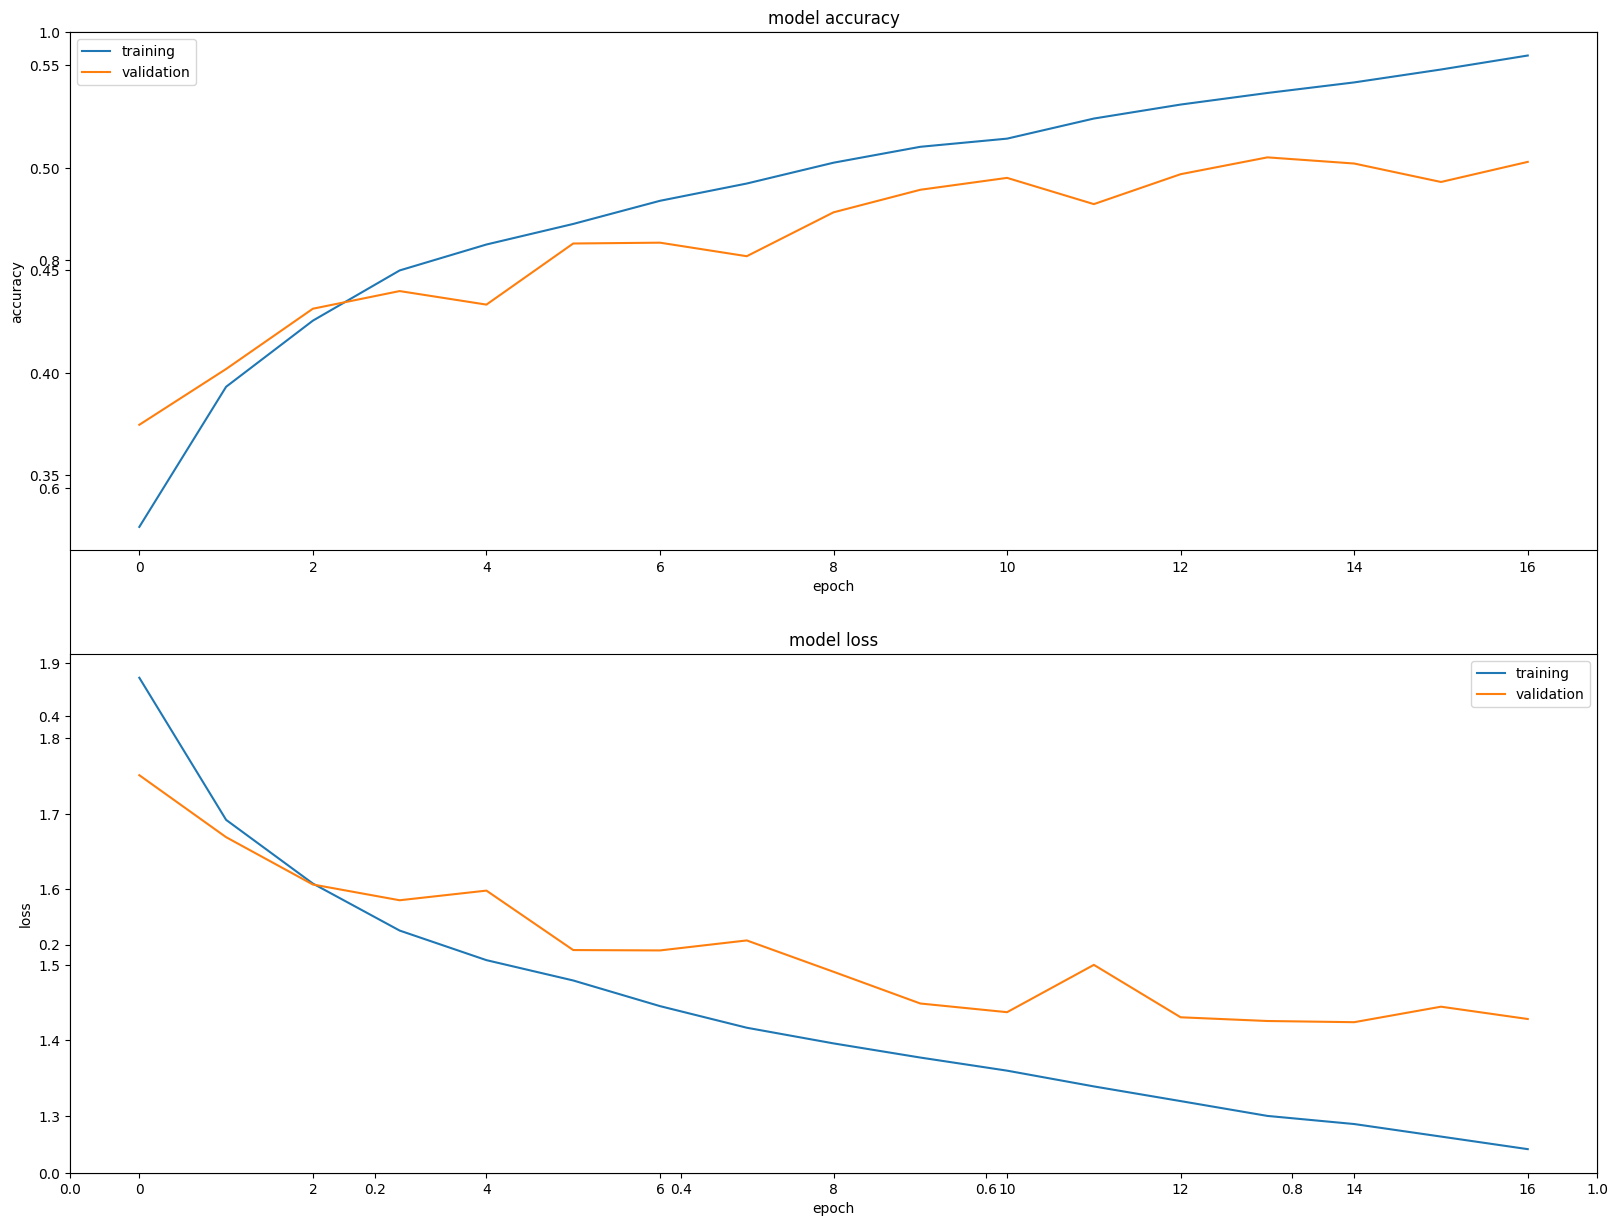

In [ ]:
history1, time1 = compile_train_model(
    dnn2,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    epochs=200,
    batch_size=64
)

history_df1 = plot_history_df(history1)


In [ ]:
model1 = tf.keras.models.load_model("CNN_model.keras", custom_objects={'softmax_v2': tf.keras.activations.softmax})

test_loss, test_acc = model1.evaluate(x_test_norm, y_test, verbose=0)
print(f"Test acc: {test_acc:.3f} | Test loss: {test_loss:.3f}")



Test acc: 0.505 | Test loss: 1.411


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.55      0.60      0.57      1000
           1       0.56      0.67      0.61      1000
           2       0.39      0.36      0.37      1000
           3       0.35      0.37      0.36      1000
           4       0.55      0.29      0.38      1000
           5       0.46      0.35      0.40      1000
           6       0.48      0.65      0.55      1000
           7       0.53      0.56      0.55      1000
           8       0.64      0.62      0.63      1000
           9       0.53      0.56      0.55      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.50      0.50     10000
weighted avg       0.51      0.51      0.50     10000

Accuracy Score: 0.505
Root Mean Square Error: 3.1204166388480883


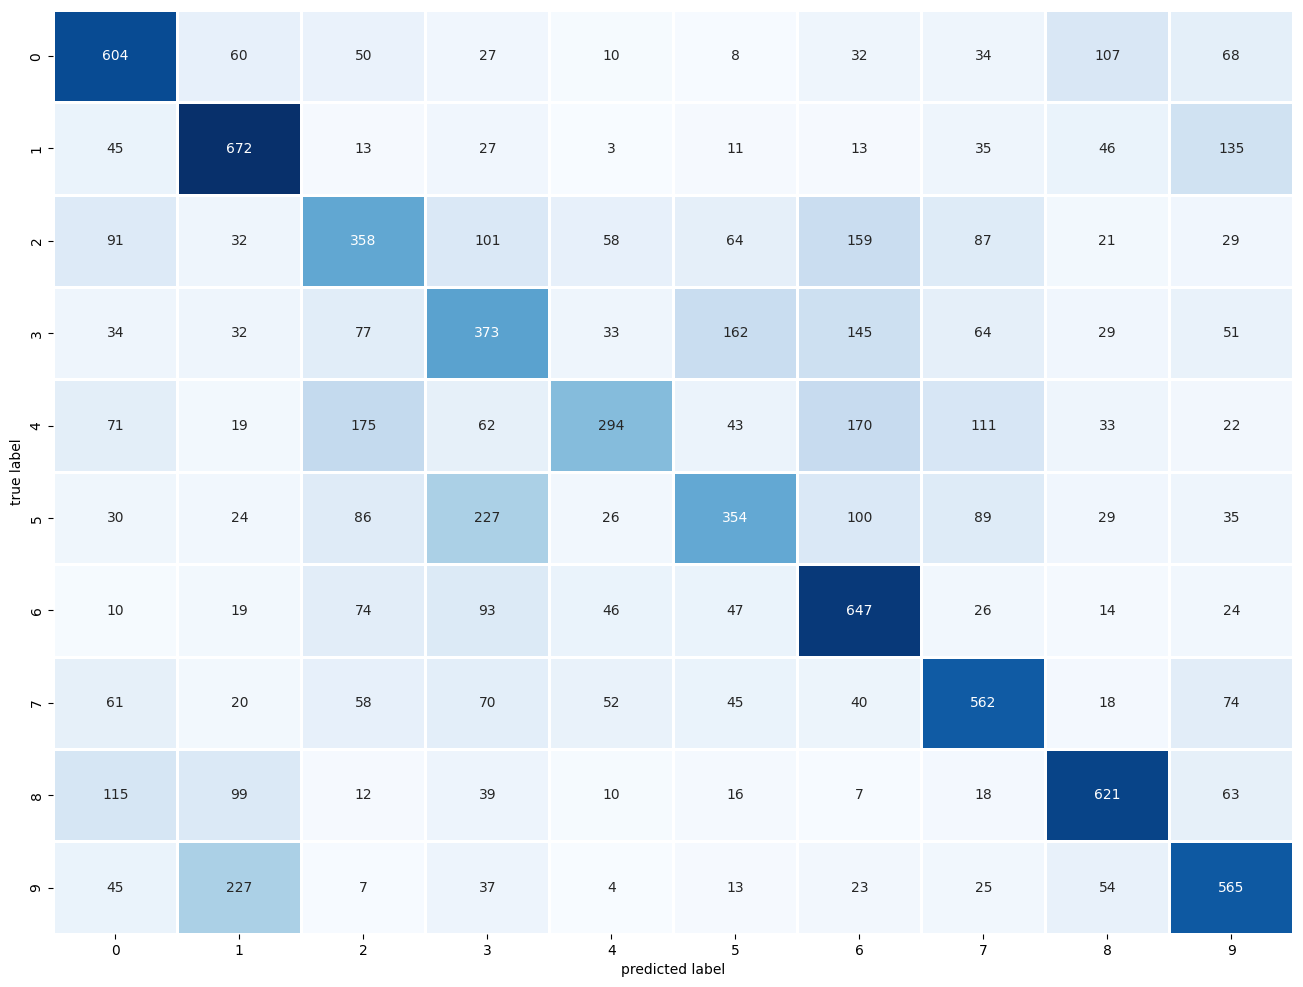

In [ ]:
pred_probs = model1.predict(x_test_norm)
pred_labels = np.argmax(pred_probs, axis=1)

print_validation_report(y_test, pred_labels)
plot_confusion_matrix(y_test, pred_labels)



In [ ]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)
df_probs = pd.DataFrame(pred_probs[0:20], columns=class_names)
df_probs.style.format("{:.2%}").background_gradient(cmap=cm)


,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
0,3.61%,22.50%,2.67%,35.10%,2.49%,19.73%,0.83%,1.09%,6.96%,5.01%
1,14.24%,25.48%,1.07%,0.07%,0.01%,0.08%,0.04%,0.12%,15.03%,43.87%
2,40.33%,23.15%,0.19%,0.03%,0.14%,0.02%,0.00%,0.14%,30.65%,5.34%
3,49.97%,5.42%,3.98%,0.87%,5.42%,0.64%,0.12%,10.48%,20.81%,2.30%
4,0.35%,0.03%,2.86%,6.93%,54.45%,4.75%,29.90%,0.43%,0.28%,0.01%
5,3.42%,4.20%,1.65%,19.69%,1.02%,9.05%,56.34%,3.83%,0.05%,0.74%
6,9.17%,35.92%,2.13%,31.40%,0.22%,12.60%,3.03%,0.38%,0.98%,4.17%
7,0.77%,0.39%,8.24%,4.98%,2.03%,1.33%,81.03%,0.17%,0.06%,1.00%
8,4.76%,0.24%,23.46%,8.23%,15.34%,13.80%,1.34%,30.49%,2.23%,0.12%
9,0.72%,79.86%,1.10%,2.13%,0.20%,0.73%,0.06%,0.62%,5.44%,9.15%


In [ ]:
results = []

# Evaluate train/val too (for the table requirement)
train_loss, train_acc = model1.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss, val_acc     = model1.evaluate(x_valid_norm, y_valid_split, verbose=0)

results.append({
    "experiment": "Exp1_DNN_2hidden_no_reg",
    "params": model1.count_params(),
    "train_loss": train_loss,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_acc": val_acc,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "train_time_sec": time1,
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history1.history["loss"])
})

pd.DataFrame(results)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp1_DNN_2hidden_no_reg,1255882,1.244229,0.559467,1.423928,0.502,1.411031,0.505,164.68,adam,64,17


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

base_dir = "/content/drive/MyDrive/MSDS458_RA02_Experiments"
os.makedirs(base_dir, exist_ok=True)

print("Saving experiments to:", base_dir)


Saving experiments to: /content/drive/MyDrive/MSDS458_RA02_Experiments


In [ ]:
exp_name = "Exp1_DNN_2hidden_no_reg"

checkpoint_path = f"{base_dir}/{exp_name}.keras"

callbacks=[
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        save_best_only=True,
        save_weights_only=False
    ),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]


In [ ]:
#RELOAD
#exp_name = "Exp1_DNN_2hidden_no_reg"
#checkpoint_path = f"{base_dir}/{exp_name}.keras"

#model = tf.keras.models.load_model(
    #checkpoint_path,
    #custom_objects={'softmax_v2': tf.keras.activations.softmax}
#)

#print("Reloaded:", exp_name)


# Experiment 2 (DNN with 3 hidden layers, no regularization)

In [ ]:
k.clear_session()



In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as k
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Train/Val split (10% val like your setup)
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=0.10, random_state=SEED, shuffle=True
)

# Normalize
x_train_norm = x_train_split.astype("float32") / 255.0
x_valid_norm = x_valid_split.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("Train:", x_train_norm.shape, y_train_split.shape)
print("Valid:", x_valid_norm.shape, y_valid_split.shape)
print("Test :", x_test_norm.shape,  y_test.shape)




170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (45000, 32, 32, 3) (45000, 1)
Valid: (5000, 32, 32, 3) (5000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
import time
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer="adam",
                        batch_size=64,
                        epochs=200,
                        patience=3):

    # Compile
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )

    # Early stopping
    callbacks = [
        EarlyStopping(
            monitor="val_accuracy",
            patience=patience,
            restore_best_weights=True
        )
    ]

    # Train + time it
    start = time.time()

    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    end = time.time()
    train_time = end - start

    print(f"\nFinished training {exp_name} in {train_time:.2f} seconds")

    return history, train_time




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_history_df(history):
    df = pd.DataFrame(history.history)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(df["accuracy"], label="train")
    plt.plot(df["val_accuracy"], label="validation")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(df["loss"], label="train")
    plt.plot(df["val_loss"], label="validation")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.show()

    return df


Model: "Exp2_DNN_3hidden_no_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.2747 - loss: 2.0121 - val_accuracy: 0.3512 - val_loss: 1.7604
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3878 - loss: 1.7071 - val_accuracy: 0.4008 - val_loss: 1.6490
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.4220 - loss: 1.6073 - val_accuracy: 0.4238 - val_loss: 1.5939
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4433 - loss: 1.5445 - val_accuracy: 0.4364 - val_loss: 1.5616
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.4619 - loss: 1.4963 - val_accuracy: 0.4548 - val_loss: 1.5225
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.4769 - loss: 1.4570 - val_accuracy: 0.4580 - val_loss: 1.5201
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.4834 - loss: 1.4314 - val_accuracy: 0.4580 - val_loss: 1.5089
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.4967 - loss: 1

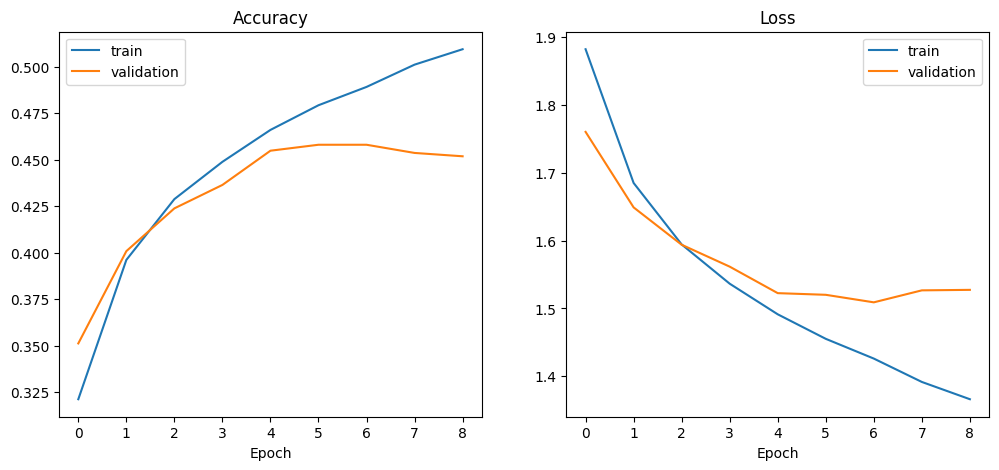


Test Accuracy: 0.471
Test Loss: 1.494


In [ ]:
from tensorflow.keras import backend as k
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# --- Experiment 2 ---
k.clear_session()
exp_name = "Exp2_DNN_3hidden_no_reg"

dnn3 = Sequential([
    Input(shape=(32,32,3)),
    Flatten(),

    Dense(512, activation="relu"),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
], name=exp_name)

dnn3.summary()

# Train
history2, train_time2 = compile_train_model(
    dnn3, exp_name,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    epochs=200,
    batch_size=64
)

# Plot curves
history_df2 = plot_history_df(history2)

# Test evaluation
test_loss2, test_acc2 = dnn3.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc2:.3f}")
print(f"Test Loss: {test_loss2:.3f}")


In [ ]:

if "results_df" not in globals():
    results_df = pd.DataFrame(columns=[
        "experiment","params",
        "train_loss","train_acc",
        "val_loss","val_acc",
        "test_loss","test_acc",
        "train_time_sec",
        "optimizer","batch_size","epochs_ran"
    ])

# Extract final epoch metrics
train_loss2 = history2.history["loss"][-1]
train_acc2  = history2.history["accuracy"][-1]
val_loss2   = history2.history["val_loss"][-1]
val_acc2    = history2.history["val_accuracy"][-1]

# Append row
results_df.loc[len(results_df)] = [
    exp_name,
    dnn3.count_params(),
    train_loss2, train_acc2,
    val_loss2, val_acc2,
    test_loss2, test_acc2,
    train_time2,
    "adam",
    64,
    len(history2.history["loss"])
]

results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp2_DNN_3hidden_no_reg,1738890,1.366026,0.509356,1.52736,0.4518,1.493653,0.4712,283.770611,adam,64,9


In [ ]:
def append_result(results_df, row_dict):
    # create df if missing
    if results_df is None:
        results_df = pd.DataFrame(columns=[
            "experiment","params",
            "train_loss","train_acc",
            "val_loss","val_acc",
            "test_loss","test_acc",
            "train_time_sec",
            "optimizer","batch_size","epochs_ran"
        ])

    # prevent duplicates by experiment name
    if "experiment" in results_df.columns and (results_df["experiment"] == row_dict["experiment"]).any():
        results_df = results_df[results_df["experiment"] != row_dict["experiment"]].copy()

    return pd.concat([results_df, pd.DataFrame([row_dict])], ignore_index=True)


In [ ]:
# Re-evaluate Exp2 quickly if needed
test_loss2, test_acc2 = dnn3.evaluate(x_test_norm, y_test, verbose=0)

row2 = {
    "experiment": "Exp2_DNN_3hidden_no_reg",
    "params": dnn3.count_params(),

    "train_loss": history2.history["loss"][-1],
    "train_acc": history2.history["accuracy"][-1],

    "val_loss": history2.history["val_loss"][-1],
    "val_acc": history2.history["val_accuracy"][-1],

    "test_loss": float(test_loss2),
    "test_acc": float(test_acc2),

    # FIX HERE:
    "train_time_sec": float(train_time2),

    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history2.history["loss"])
}

row2



{'experiment': 'Exp2_DNN_3hidden_no_reg',
 'params': 1738890,
 'train_loss': 1.3660258054733276,
 'train_acc': 0.5093555450439453,
 'val_loss': 1.527360200881958,
 'val_acc': 0.45179998874664307,
 'test_loss': 1.493652582168579,
 'test_acc': 0.47119998931884766,
 'train_time_sec': 283.77061104774475,
 'optimizer': 'adam',
 'batch_size': 64,
 'epochs_ran': 9}

In [ ]:
results_df = append_result(results_df, row2)

results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp2_DNN_3hidden_no_reg,1738890,1.366026,0.509356,1.52736,0.4518,1.493653,0.4712,283.770611,adam,64,9
